## Importar las Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración para gráficos más nítidos
plt.rcParams["figure.figsize"] = (8, 5)
plt.style.use("ggplot")


# 1. Carga del dataset Clientes (JSon)
Cargar los datos de clientes desde el archivo JSON y mostrar la cantidad total de clientes.

In [2]:
clientes = pd.read_json("clientes.json")

cantidad_clientes = len(clientes)
print("Cantidad total de clientes:", cantidad_clientes)

Cantidad total de clientes: 10


# 2. Inspección de los datos.

In [3]:
print("\n--- Visualización previa de las primeras 5 filas ---")
clientes.head()


--- Visualización previa de las primeras 5 filas ---


,ID_CLIENTE,NOMBRE,CIUDAD,PROVINCIA,EDAD,SEGMENTO
0,C001,Ana García,Buenos Aires,Buenos Aires,34,Frecuente
1,C002,Carlos López,La Plata,Buenos Aires,42,Ocasional
2,C003,María Rodríguez,Córdoba,Córdoba,29,Frecuente
3,C004,Juan Martínez,Rosario,Santa Fe,38,Frecuente
4,C005,Laura Fernández,Mendoza,Mendoza,31,Premium


In [4]:
print("\n--- Información general ---")
clientes.info()


--- Información general ---
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID_CLIENTE  10 non-null     str  
 1   NOMBRE      10 non-null     str  
 2   CIUDAD      10 non-null     str  
 3   PROVINCIA   10 non-null     str  
 4   EDAD        10 non-null     int64
 5   SEGMENTO    10 non-null     str  
dtypes: int64(1), str(5)
memory usage: 1.0 KB


In [5]:
print("\n--- Estadísticas descriptivas — variables numéricas ---")
clientes.describe()


--- Estadísticas descriptivas — variables numéricas ---


,EDAD
count,10.000000
mean,35.500000
std,7.763876
min,25.000000
25%,29.500000
50%,35.000000
75%,41.000000
max,48.000000


# 3. Visualización Univariada

## Histograma y Boxplot para observar la distribución y detectar posibles outliers.

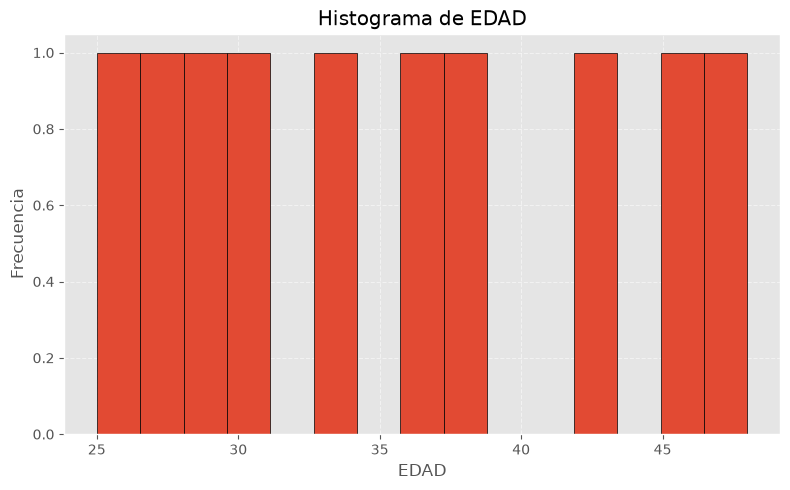

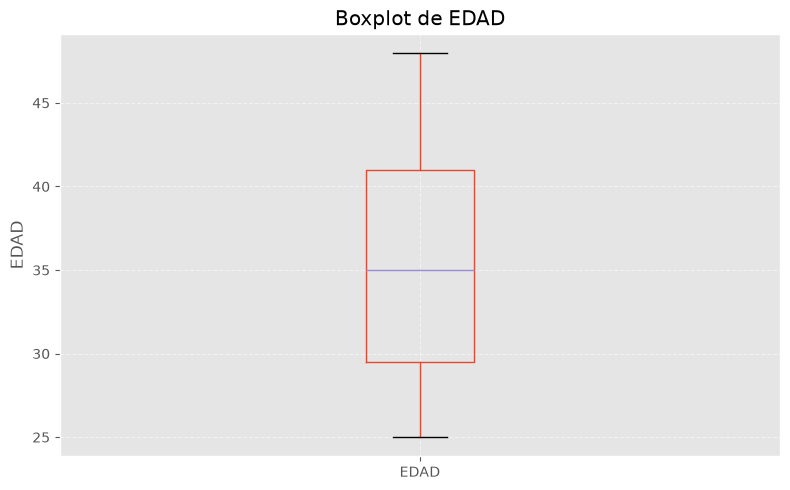

In [6]:
# Seleccionamos solo la columna numérica 'EDAD' 

# Histograma
clientes['EDAD'].hist(bins=15, edgecolor='black')
plt.title('Histograma de EDAD')
plt.xlabel('EDAD')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Boxplot
clientes.boxplot(column='EDAD')
plt.title('Boxplot de EDAD')
plt.ylabel('EDAD')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Creación de diferentes tipos de gráficos, se busca identificar patrones, distribuciones, relaciones y posibles outliers en los datos.

### Gráfico 1 — Cantidad de clientes por SEGMENTO

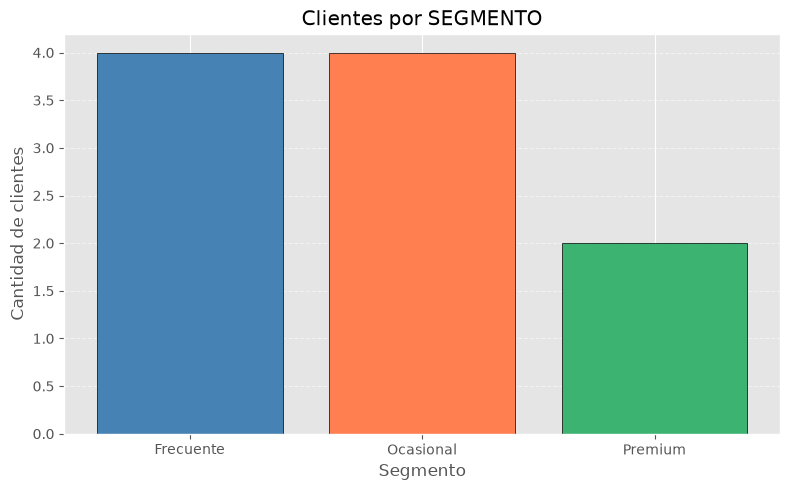

In [7]:
segmento_counts = clientes['SEGMENTO'].value_counts()

plt.bar(segmento_counts.index, segmento_counts.values,
        color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
plt.title('Clientes por SEGMENTO')
plt.xlabel('Segmento')
plt.ylabel('Cantidad de clientes')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Gráfico 2 — Distribución por PROVINCIA

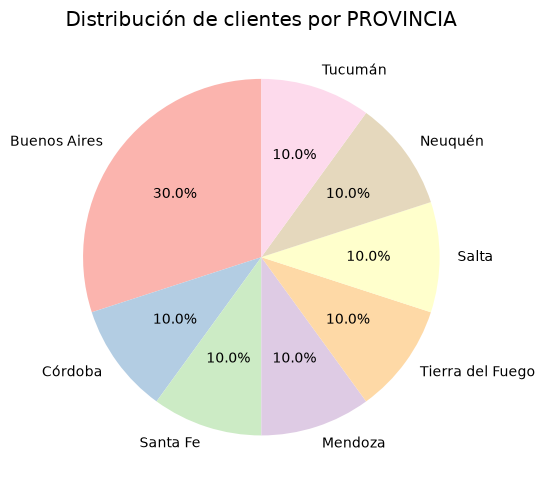

In [8]:
provincia_counts = clientes['PROVINCIA'].value_counts()

plt.pie(provincia_counts.values, labels=provincia_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=plt.cm.Pastel1.colors)
plt.title('Distribución de clientes por PROVINCIA')
plt.tight_layout()
plt.show()

### Gráfico 3 — EDAD promedio por SEGMENTO

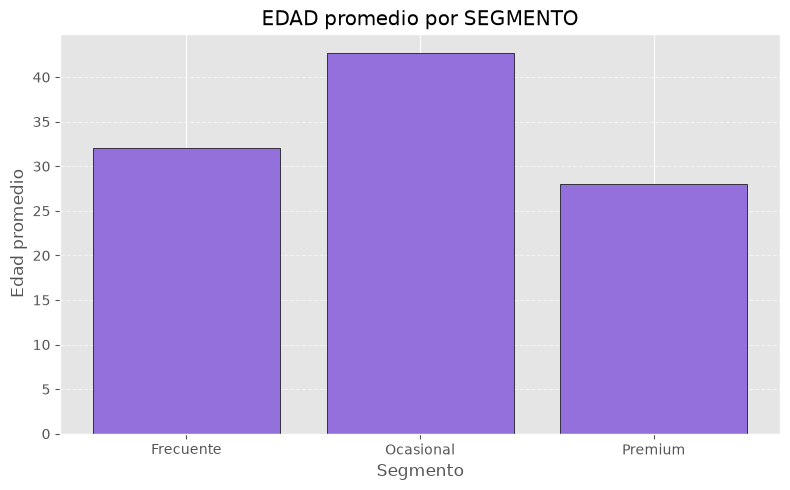

In [9]:
edad_por_segmento = clientes.groupby('SEGMENTO')['EDAD'].mean()

plt.bar(edad_por_segmento.index, edad_por_segmento.values,
        color='mediumpurple', edgecolor='black')
plt.title('EDAD promedio por SEGMENTO')
plt.xlabel('Segmento')
plt.ylabel('Edad promedio')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Gráfico 4 — EDAD por SEGMENTO — Boxplot comparativo

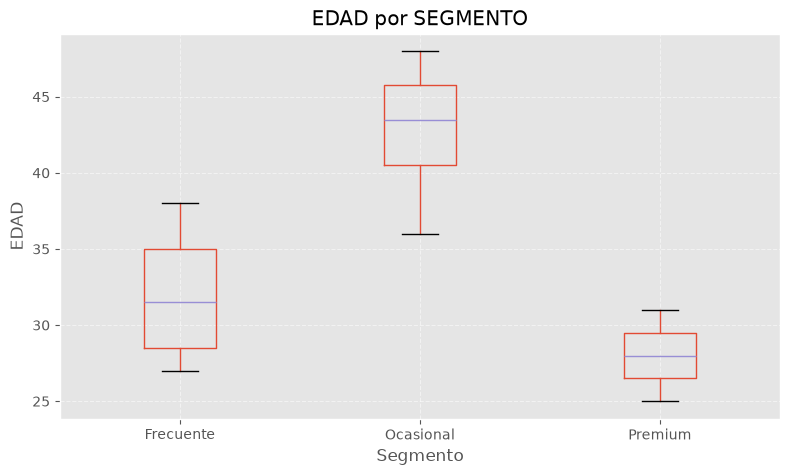

In [10]:
clientes.boxplot(column='EDAD', by='SEGMENTO')
plt.title('EDAD por SEGMENTO')
plt.suptitle('')  # quita el título automático de pandas
plt.xlabel('Segmento')
plt.ylabel('EDAD')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Relaciones entre variables - Matriz de Correalción

### El dataset "CLIENTES sólo tiene una columna numérica 'EDAD'. 
Una matriz de correlación necesita al menos 2 variables numéricas.

# 5. Identificación de Outliers con regla IQR

In [11]:
Q1 = clientes['EDAD'].quantile(0.25)
Q3 = clientes['EDAD'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

outliers = clientes[(clientes['EDAD'] < Q1 - 1.5*IQR) | (clientes['EDAD'] > Q3 + 1.5*IQR)]

print(f"\nCantidad de outliers en Edad: {len(outliers)}")
print(outliers)

Q1 = 29.5
Q3 = 41.0
IQR = 11.5

Cantidad de outliers en Edad: 0
Empty DataFrame
Columns: [ID_CLIENTE, NOMBRE, CIUDAD, PROVINCIA, EDAD, SEGMENTO]
Index: []


In [12]:
print (clientes)

  ID_CLIENTE           NOMBRE                 CIUDAD         PROVINCIA  EDAD  \
0       C001       Ana García           Buenos Aires      Buenos Aires    34   
1       C002     Carlos López               La Plata      Buenos Aires    42   
2       C003  María Rodríguez                Córdoba           Córdoba    29   
3       C004    Juan Martínez                Rosario          Santa Fe    38   
4       C005  Laura Fernández                Mendoza           Mendoza    31   
5       C006    Diego Sánchez                Ushuaia  Tierra del Fuego    45   
6       C007     Sofía Torres                  Salta             Salta    27   
7       C008    Martín Romero                Neuquén           Neuquén    36   
8       C009   Valentina Díaz          Mar del Plata      Buenos Aires    25   
9       C010    Pablo Herrera  San Miguel de Tucumán           Tucumán    48   

    SEGMENTO  
0  Frecuente  
1  Ocasional  
2  Frecuente  
3  Frecuente  
4    Premium  
5  Ocasional  
6  Frecuente  